### 1b. Change of Mind and behavior learning curve

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from ripple_detection.core import segment_boolean_series

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2025-11-09 18:23:51,687][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,MUA,get_linearization_map,ChangeofMind
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.ripple_add_replay import plot_decode_spiking
from spyglass.shijiegu.changeOfMind import (normalize)
from spyglass.shijiegu.changeOfMind_triggered import fitLM
import statsmodels.api as sm

[18:23:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:23:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:23:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:23:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:23:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [5]:
seq1=[1,3,2,4];
seq2=[1,3,4,2];
seq3=[1,2,3,4];

rev1=[1,4,2,3];
rev2=[1,2,4,3];
rev3=[1,4,3,2];

seqs=np.vstack((seq1,seq2,seq3,rev1,rev2,rev3))
orders=['Seq1','Seq2','Seq3','Rev1','Rev2','Rev3'] #'1st repeat','2nd repeat','3rd repeat'

P_task=np.zeros((4,4,6))
for s in range(6):
    for a in range(4):
        P_task[seqs[s,a%4]-1,seqs[s,(a+1)%4]-1,s]=1
        
def find_behavior_transitions(index,outers): #P(xi|xj)
    '''returns numbers of transition'''
    T=np.zeros((4,4))
    for t in range(len(outers)-1):
        if (index[t+1]-index[t])==1: #adjacent trials
            T[int(outers[t])-1,int(outers[t+1])-1] += 1 # minus 1 due to python indexing
    #for ti in range(4):
    #    T[ti]=T[ti]/np.sum(T[ti])
    
    return T
    
def matrix_distance(M1,M2):
    return np.linalg.norm(M1-M2)

def find_distance(dates_to_plot,behavior_data):
    distances = {}
    
    for day in dates_to_plot:
        total_trial_num_day = 0
        occurance_rates_day = np.zeros(6)
        
        subset_ind = np.argwhere(behavior_data['dateIntAll'] == int(day)).ravel()
    
        # initialize matrix:
        distance = []
        trial_num = []
        for session_ind in subset_ind:
            outers = behavior_data['outersAll'][session_ind]
            P_target_session = P_task[:,:,behavior_data['seqtype_int'][session_ind]-1] #minus 1 for 0 indexing
            
            # form matrix
            P_session = normalize(find_behavior_transitions(np.arange(len(outers)),outers))
            # add to matrix
            distance.append(matrix_distance(P_target_session, P_session))
            trial_num.append(len(outers))
        distances[day] = np.sum(distance * (trial_num / np.sum(trial_num)))

    return distances

def fit_linear_to_distance(distances):
    """This function works with find_distance()"""
    y = [distances[d] for d in distances]
    x = np.arange(len(y))
    results, pvalue = fitLM(x, y)
    k = results.params[1]

    return results,pvalue,x,y,k

def find_perfect_sequence_learning(behavior_data):
    total_trial_num = {}
    occurance_rates = {}
    
    for day in dates_to_plot:
        total_trial_num_day = 0
        occurance_rates_day = np.zeros(6)
        
        subset_ind = np.argwhere(behavior_data['dateIntAll'] == int(day)).ravel()
        for session_ind in subset_ind:
            total_trial_num_day = total_trial_num_day + len(behavior_data['outersAll'][session_ind])
            for seq in range(6):
                occurance_rates_day[seq] = occurance_rates_day[seq] + np.mean(behavior_data['occurance_rates'][seq][session_ind])
        occurance_rates_day = occurance_rates_day/len(subset_ind)
        
        total_trial_num[day] = total_trial_num_day
        occurance_rates[day] = occurance_rates_day
    return total_trial_num, occurance_rates

def find_COM_trials(animal, dates_to_plot, proportion_threshold = 0.1):
    """return the number of COM trials for each day in dates_to_plot"""
    #trials_days = find_trials_animal(animal,dates_to_plot,proportion_threshold = proportion_threshold)

    trial_number = []
    for day in dates_to_plot:
        
        trial_number_d = 0
        total_trial_number_d = 0
        
        nwb_file_name = animal.lower() + day + '.nwb'
        nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
        session_interval, position_interval = runSessionNames(nwb_copy_file_name)
        
        for session in session_interval:
            q = {"nwb_file_name":nwb_copy_file_name,
                 "epoch":int(session[:2]), "proportion": proportion_threshold}
            q_result = ChangeofMind() & q
            if len(q_result) == 0:
                continue
            info_table = ChangeofMind().fetch1_dataframe(q)
            #info_table = pd.read_pickle(info)
            
            total_trial_number_d += (len(info_table)-1)
            trial_number_d += len(np.argwhere(np.array(info_table.change_of_mind) == True).ravel())
        #print(f"{day} has {total_trial_number_d} trials.")
        if trial_number_d == 0:
            trial_number.append(0)
        else:
            trial_number.append(trial_number_d / total_trial_number_d)
    return trial_number

In [6]:
def return_perfect_sequence_COM_trial_count(animal, dates_to_plot, behavior_datafolder):
    # load behavior data
    sequence_datapath = os.path.join(behavior_datafolder,'behavior_metaSequence_'+animal+'.p')
    with open(sequence_datapath, 'rb') as f:
        behavior_data = pickle.load(f)  
    
    # get learning curve of 2 sorts
    distances = find_distance(dates_to_plot,behavior_data)
    (total_trial_num, occurance_rates) = find_perfect_sequence_learning(behavior_data)
    
    # find change of mind trials
    rate1 = find_COM_trials(animal,dates_to_plot,proportion_threshold = 0.05)
    rate2 = find_COM_trials(animal,dates_to_plot,proportion_threshold = 0.1)
    rate3 = find_COM_trials(animal,dates_to_plot,proportion_threshold = 0.2)

    return distances,occurance_rates,total_trial_num,rate1,rate2,rate3

In [10]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
distances_animals = {}
total_trial_num_animals = {}
perf_seq_rates_animals = {}
(COM_rate_animals1, COM_rate_animals2, COM_rate_animals3) = ({}, {}, {})


In [7]:
animal = 'Eliot'
animal_save_name = 'Eliot'

target_sequence_animal = 1
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221017','20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [14]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

[2025-10-04 13:20:17,405][WARNING]: Skipped checksum for file with hash: fa566d4d-cff0-9dd8-a9ef-64bee6d50a4a, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_M4RQRUKUKB.nwb
[2025-10-04 13:20:22,465][WARNING]: Skipped checksum for file with hash: 675fe116-456a-1ec2-1dc7-3d4a0481359a, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_EB1GLBVPH0.nwb
[2025-10-04 13:20:27,591][WARNING]: Skipped checksum for file with hash: 3eb32ff5-7051-64f4-0a45-5dfff13207f7, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_KYIDN3MU42.nwb
[2025-10-04 13:20:32,582][WARNING]: Skipped checksum for file with hash: ff60e977-206e-6f93-2f21-8617f3e28b82, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_M7LGZQ5N8M.nwb
[2025-10-04 13:20:37,619][WARNING]: Skipped checksum for file with hash: e4e4d713-2995-72d8-16b4-d8799681f604, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VT8R484WNA.nwb
[2025-10-04 13:20:42,568][WARNING]: Skipped checksum for file with hash: d2

In [30]:
file_path = f"{output_folder}/{animal_save_name}_learning.pickle"
data = {}
data["distances_animal"] = distances_animals[animal_save_name]
data["perf_seq_rates_animal"] = perf_seq_rates_animals[animal_save_name]
data["total_trial_num_animal"] = total_trial_num_animals[animal_save_name]
data["COM_rate_animal1"] = COM_rate_animals1[animal_save_name]
data["COM_rate_animal2"] = COM_rate_animals2[animal_save_name]
data["COM_rate_animal3"] = COM_rate_animals3[animal_save_name]
data["target_sequence_animal"] = target_sequence_animals[animal_save_name]

with open(file_path, 'wb') as file:
    pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")


Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_learning.pickle


In [24]:
animal = 'Lewis'
animal_save_name = 'Lewis1'
target_sequence_animals = {}
target_sequence_animals['Lewis1'] = 4

dates_to_plot = ['20240102','20240103','20240104','20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [25]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

[2025-10-24 10:55:06,603][WARNING]: Skipped checksum for file with hash: 1cc15d5f-4f08-851d-9dea-6b68e196fc6b, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_IP1BV7QP74.nwb
[2025-10-24 10:55:15,525][WARNING]: Skipped checksum for file with hash: 2ba27bd1-39f7-ee41-db37-5648b44aca17, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_GAB9641WP6.nwb
[2025-10-24 10:55:24,343][WARNING]: Skipped checksum for file with hash: c87b413a-1c72-6868-0150-c27c5856f8e1, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_W7T8EQDLL2.nwb
[2025-10-24 10:55:33,074][WARNING]: Skipped checksum for file with hash: 8e8bb285-681f-3cf4-d591-9b47d5e8f9c0, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_60Y3P0XR2K.nwb
[2025-10-24 10:55:41,761][WARNING]: Skipped checksum for file with hash: 4c8a4903-0fed-f7ab-4e20-3d7fbe803dad, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_RZ6JOAK5IM.nwb
[2025-10-24 10:55:50,491][WARNING]: Skipped checksum for file with hash: 2b

In [127]:
animal = 'Lewis'
animal_save_name = 'Lewis2'
dates_to_plot = ['20240116','20240117','20240118','20240119','20240120']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [128]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

In [125]:
animal = 'Haydn'
animal_save_name = 'Haydn'
dates_to_plot = ['20230603','20230604','20230605','20230606','20230607','20230608']
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [126]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

In [120]:
animal = 'Molly'
animal_save_name = 'Molly'
dates_to_plot = ['20220415','20220416','20220417','20220418','20220419','20220420']
datafolder = f'/stelmo/shijie/behavior_pilot/Batch1/{animal}'

In [121]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

In [41]:
animal = 'Klein'
animal_save_name = 'Klein'
# " 20231110 has problems "
dates_to_plot = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'
target_sequence_animals['Klein'] = 4

In [ ]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

[2025-11-01 22:14:08,109][WARNING]: Skipped checksum for file with hash: cb5de655-8a83-7fd5-fb16-105d230c6047, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_UT29JV8GXY.nwb
[2025-11-01 22:14:17,277][WARNING]: Skipped checksum for file with hash: 00e0f7bd-dc12-3d9a-c0a8-face0391823f, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_I29O1SD16Y.nwb
[2025-11-01 22:14:26,126][WARNING]: Skipped checksum for file with hash: 70007a05-f2a4-75ac-d709-8b8abb22e4f9, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_KMTHU3E02L.nwb
[2025-11-01 22:14:34,945][WARNING]: Skipped checksum for file with hash: 946f88d5-812a-151f-e17c-b99af2c1fdc4, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_B3845SMBHU.nwb
[2025-11-01 22:14:43,669][WARNING]: Skipped checksum for file with hash: c565add6-6937-605a-ffd1-0bf3d345ac03, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_LINF0W94S9.nwb
[2025-11-01 22:14:52,551][WARNING]: Skipped checksum for file with hash: 3d

In [127]:
animal = 'Julio'
animal_save_name = 'Julio'
dates_to_plot = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'
target_sequence_animals['Julio'] = 1

In [44]:
(distances_animals[animal_save_name],
 perf_seq_rates_animals[animal_save_name],
 total_trial_num_animals[animal_save_name],
 COM_rate_animals1[animal_save_name],
 COM_rate_animals2[animal_save_name],
 COM_rate_animals3[animal_save_name]) = return_perfect_sequence_COM_trial_count(
    animal, dates_to_plot, datafolder)

file_path = f"{output_folder}/{animal_save_name}_learning.pickle"
data = {}
data["distances_animal"] = distances_animals[animal_save_name]
data["perf_seq_rates_animal"] = perf_seq_rates_animals[animal_save_name]
data["total_trial_num_animal"] = total_trial_num_animals[animal_save_name]
data["COM_rate_animal1"] = COM_rate_animals1[animal_save_name]
data["COM_rate_animal2"] = COM_rate_animals2[animal_save_name]
data["COM_rate_animal3"] = COM_rate_animals3[animal_save_name]
data["target_sequence_animal"] = target_sequence_animals[animal_save_name]

with open(file_path, 'wb') as file:
    pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")

[2025-11-04 10:17:48,145][WARNING]: Skipped checksum for file with hash: cb5de655-8a83-7fd5-fb16-105d230c6047, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_UT29JV8GXY.nwb


KeyboardInterrupt: 

In [ ]:
COM_rate_animals3.keys()

### 1. Plot learning speed vs C-o-M pct

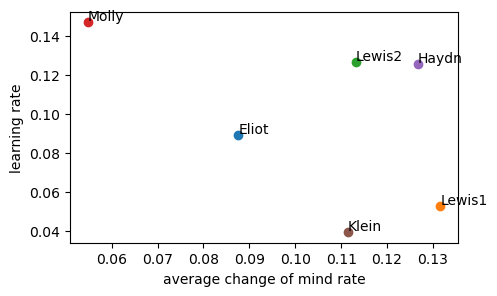

In [133]:
fig, ax1 = plt.subplots(1, 1, figsize=(5, 3),sharex=True)
for k in ["Eliot","Lewis1","Lewis2","Molly","Haydn","Klein"]:
    x = np.mean(COM_rate_animals1[k])
    results,pvalue,_,__,k_animals = fit_linear_to_distance(distances_animals[k])
    y = -k_animals
    ax1.scatter(x,y)
    ax1.text(x,y+0.001,k)
ax1.set_xlabel('average change of mind rate');
ax1.set_ylabel('learning rate');

### 2. Plot individual learning curves

In [35]:
def plot(animal, distances_animals, perf_seq_rates_animals, total_trial_num_animals, COM_rate_animals1, COM_rate_animals2, COM_rate_animals3,
        target_sequence_animal):
    occurance_rates = perf_seq_rates_animals#[animal]
    total_trial_num = total_trial_num_animals#[animal]
    (trial_number1, trial_number2, trial_number3) = (COM_rate_animals1,#[animal],
                                                     COM_rate_animals2,#[animal],
                                                     COM_rate_animals3)#[animal]) # C-o-M trials
    
    distances = distances_animals#[animal]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4),sharex=True)

    colors = [[0.6,0.6,0.6] for k in occurance_rates]
    colors[target_sequence_animal] = 'C1'
    print(colors)
    
    occurance_rates_matrix = np.array([occurance_rates[k] for k in occurance_rates])

    line_ind = 0
    for k in range(6):
        if k == target_sequence_animal:
            ax1.plot(occurance_rates_matrix[:,line_ind], color = colors[line_ind], linewidth = 3)
        else:
            ax1.plot(occurance_rates_matrix[:,line_ind], color = colors[line_ind], alpha = 0)
        line_ind += 1
        
    ax2.plot(trial_number1, label = "10 cm in", color = 'k',linestyle = "dashed")
    ax2.plot(trial_number2, label = "20 cm in", color = 'k')
    ax2.plot(trial_number3, label = "30 cm in",color = 'k',linestyle = "dotted")
    ax2.legend(bbox_to_anchor=(1.1, 1.05))
    
    #ax3.plot([distances[k] for k in distances])
    
    y = distances
    x = np.arange(len(distances))
    results,pvalue,_,__,k_animals = fit_linear_to_distance(distances)
    
    x_plot=np.linspace(np.min(x),np.max(x),10).reshape(-1,1)
    y_plot=results.predict(sm.add_constant(x_plot))
    pvalue_beta = results.pvalues[1]
        
    #ax3.plot(x_plot,y_plot,color='grey',linewidth=1,linestyle = "-.")
    #ax3.text(np.min(x_plot),np.min(y_plot),f'p value = {np.round(pvalue_beta,4)}')
    
    ax1.text(0,0.5,animal,fontsize = 12)
    ax1.set_ylabel('full seq occurrance pct');
    ax2.set_ylabel('ch. of m. pct of all trials');
    #ax3.set_ylabel('$\|P - P_{target}\|$');
    
    dates_to_plot = list(occurance_rates.keys())
    ax2.set_xlabel('day');
    ax2.set_xticks(np.arange(len(dates_to_plot)));
    ax2.set_xticklabels(dates_to_plot, rotation = 45);

    ax1.spines[['right', 'top']].set_visible(False)
    ax2.spines[['right', 'top']].set_visible(False)
    
    plt.savefig(f"learning_curve_{animal}.pdf",bbox_inches='tight')

[[0.6, 0.6, 0.6], 'C1', [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6]]


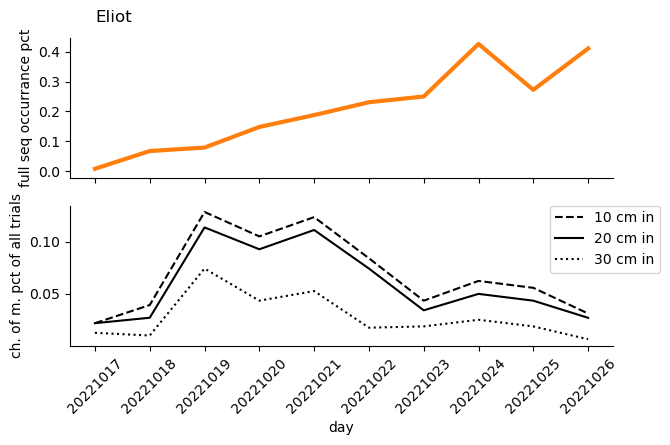

In [36]:
animal = "Eliot"
target_sequence_animal = 1
file_path = f"{output_folder}/{animal}_learning.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
plot(animal,
     data["distances_animal"], data["perf_seq_rates_animal"],
     data["total_trial_num_animal"],
     data["COM_rate_animal1"], data["COM_rate_animal2"], data["COM_rate_animal3"],
    target_sequence_animal)


[[0.6, 0.6, 0.6], 'C1', [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6]]


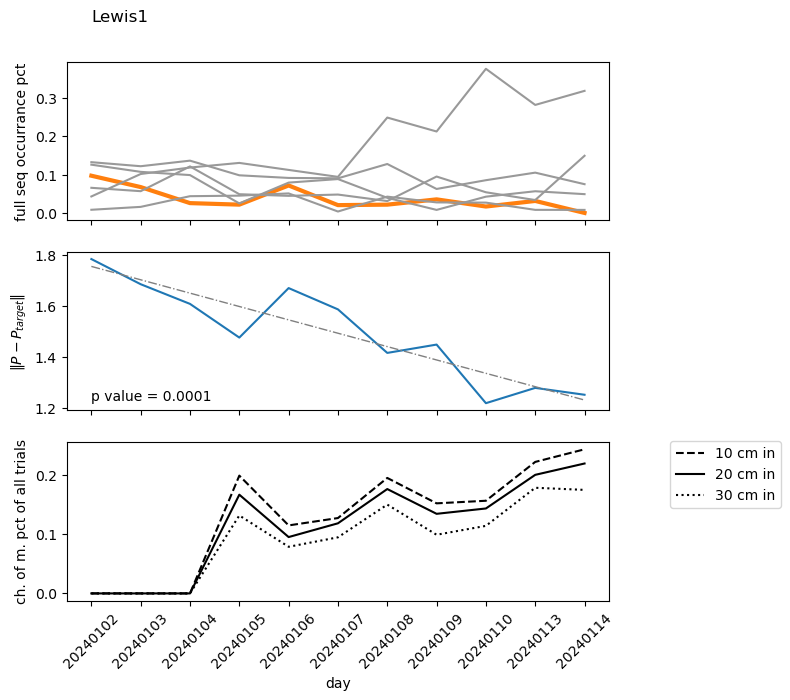

In [17]:
animal = "Lewis1"
file_path = f"{output_folder}/{animal}_learning.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
plot(animal,
     data["distances_animal"], data["perf_seq_rates_animal"],
     data["total_trial_num_animal"],
     data["COM_rate_animal1"], data["COM_rate_animal2"], data["COM_rate_animal3"],
    target_sequence_animal)

In [18]:
animal = "Lewis2"
file_path = f"{output_folder}/{animal}_learning.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
plot(animal,
     data["distances_animal"], data["perf_seq_rates_animal"],
     data["total_trial_num_animal"],
     data["COM_rate_animal1"], data["COM_rate_animal2"], data["COM_rate_animal3"],
    target_sequence_animal)

FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/figure1/Lewis2_learning.pickle'

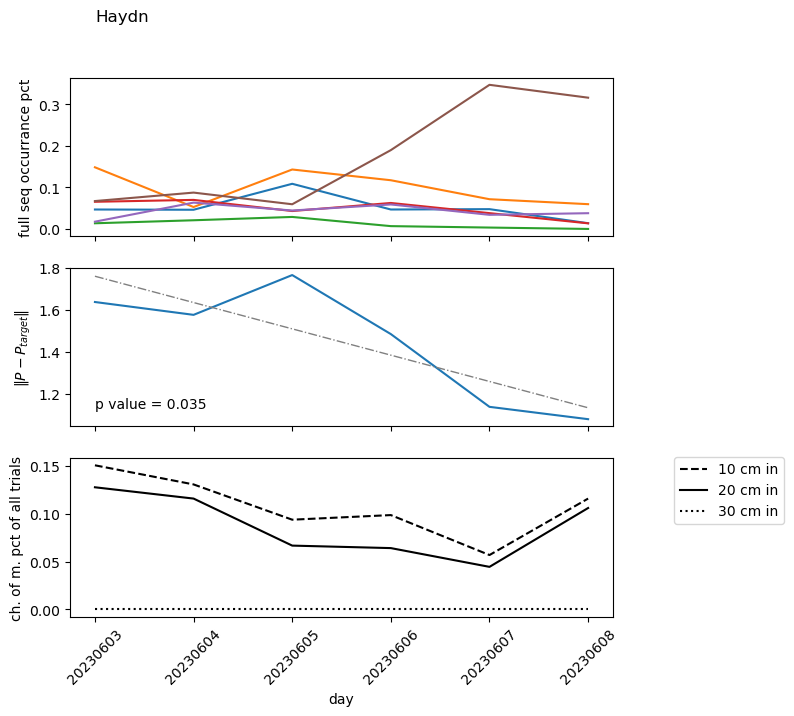

In [111]:
animal = "Haydn"

plot(animal, distances_animals, perf_seq_rates_animals, total_trial_num_animals, COM_rate_animals1, COM_rate_animals2, COM_rate_animals3)


In [19]:
animal = "Molly"
file_path = f"{output_folder}/{animal}_learning.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
plot(animal,
     data["distances_animal"], data["perf_seq_rates_animal"],
     data["total_trial_num_animal"],
     data["COM_rate_animal1"], data["COM_rate_animal2"], data["COM_rate_animal3"],
    target_sequence_animal)

FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/figure1/Molly_learning.pickle'

[[0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], 'C1', [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6]]


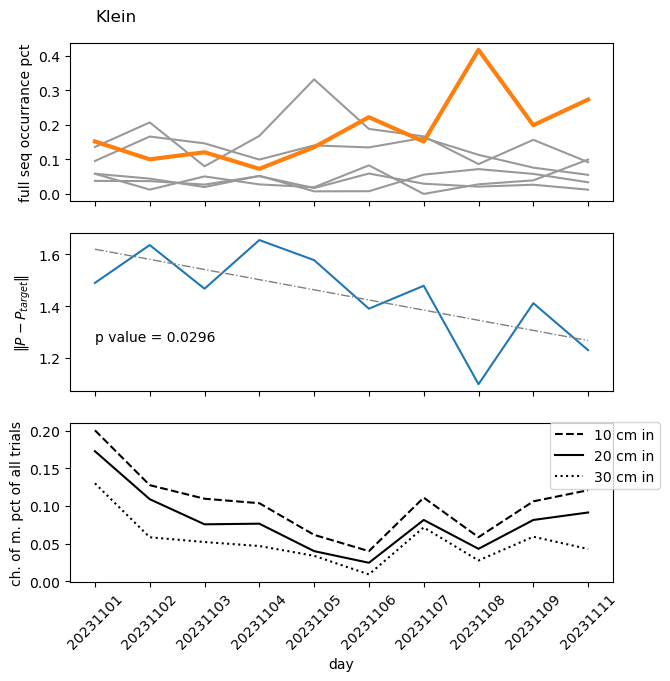

In [22]:
animal = "Klein"
file_path = f"{output_folder}/{animal}_learning.pickle"

target_sequence_animal = 4
with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
plot(animal,
     data["distances_animal"], data["perf_seq_rates_animal"],
     data["total_trial_num_animal"],
     data["COM_rate_animal1"], data["COM_rate_animal2"], data["COM_rate_animal3"],
    target_sequence_animal)

[[0.6, 0.6, 0.6], 'C1', [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6]]


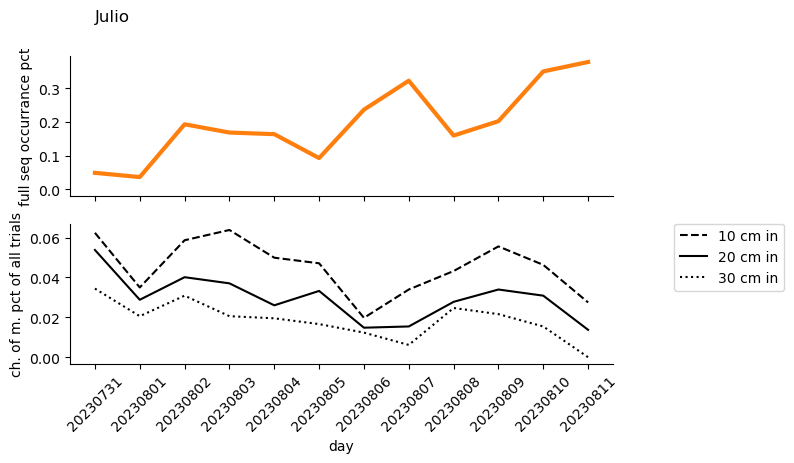

In [37]:
animal = "Julio"
file_path = f"{output_folder}/{animal}_learning.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    
plot(animal,
     data["distances_animal"], data["perf_seq_rates_animal"],
     data["total_trial_num_animal"],
     data["COM_rate_animal1"], data["COM_rate_animal2"], data["COM_rate_animal3"],
    target_sequence_animal)

# End here